In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("data/insurance_cleaned.csv")

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Model trained and predictions made!")

Model trained and predictions made!


In [2]:
mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 4177.045561036318


In [3]:
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 35478020.67523558


In [4]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 5956.342894363585


In [5]:
r2 = r2_score(y_test, predictions)
print("R² Score:", r2)

R² Score: 0.8069287081198013


In [6]:
print("=" * 40)
print("MODEL EVALUATION SUMMARY")
print("=" * 40)
print(f"MAE  (Mean Absolute Error):      {mae:.2f}")
print(f"MSE  (Mean Squared Error):       {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):  {rmse:.2f}")
print(f"R2 Score:                        {r2:.4f}")
print("=" * 40)

MODEL EVALUATION SUMMARY
MAE  (Mean Absolute Error):      4177.05
MSE  (Mean Squared Error):       35478020.68
RMSE (Root Mean Squared Error):  5956.34
R2 Score:                        0.8069


In [7]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions,
    'Difference': y_test.values - predictions
})
comparison_df.head(10)

,Actual,Predicted,Difference
0,8688.85885,8143.693884,545.164966
1,5708.86700,5737.115683,-28.248683
2,11436.73815,14369.314876,-2932.576726
3,38746.35510,31745.513636,7000.841464
4,4463.20510,8962.386657,-4499.181557
5,9304.70190,13149.722353,-3845.020453
6,38511.62830,30446.760679,8064.867621
7,2150.46900,1453.288813,697.180187
8,7345.72660,10633.018402,-3287.291802
9,10264.44210,11318.943794,-1054.501694


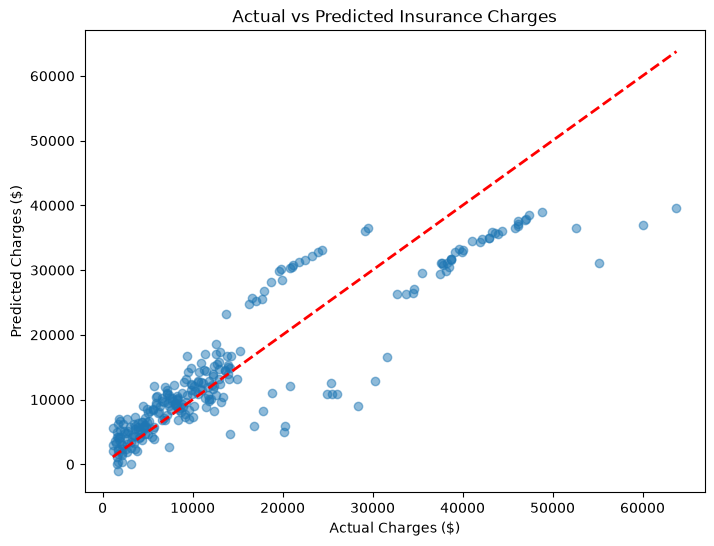

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()

## Model Evaluation — Observations

- **MAE = $4,177** → On average, the model's predictions are off by about $4,177 from the actual charges.
- **MSE = 35,478,020** → Since errors are squared, this metric is harder to interpret directly, but it confirms that larger errors are being penalized more heavily.
- **RMSE = $5,956** → The typical prediction error is around $5,956. RMSE being higher than MAE suggests there are some larger outlier errors in the predictions.
- **R² Score = 0.807** → The model explains about 80.7% of the variation in insurance charges using the given features (age, sex, bmi, children, smoker, region).

### Conclusion
The Linear Regression model performs reasonably well, especially considering it's a simple model. The `smoker` feature (identified as the strongest predictor during EDA) plays a major role in these predictions. Some errors are larger for people with high charges (likely smokers with additional risk factors not captured by these features, such as pre-existing health conditions). Future improvements could include trying more advanced models (e.g., Random Forest, Gradient Boosting) or adding more features.
